In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import sys
sys.path.insert(0, '../neuralsd')
from iterative_nsd import IterativeNSD

In [2]:
df = pd.read_csv('arcene_preproc.csv')
df.head()

,0,1,2,3,4,5,6,7,8,9,...,9991,9992,9993,9994,9995,9996,9997,9998,9999,Target
0,0,3,0,0,0,3,1,1,0,0,...,2,2,0,0,0,0,0,0,3,1
1,0,2,1,0,1,3,1,0,1,0,...,3,1,0,2,0,0,0,2,2,-1
2,0,0,0,0,0,2,1,0,0,0,...,3,0,0,0,0,0,0,0,3,1
3,0,2,1,1,0,3,2,0,0,0,...,3,0,0,1,0,1,0,0,3,1
4,2,0,2,2,0,0,1,0,0,0,...,0,0,0,0,0,2,0,0,1,-1


In [4]:
df = df.astype(str)

In [5]:
def run_bootstrap_iteration(seed):
    np.random.seed(seed)
    idx = np.random.choice(len(df), size=len(df), replace=True)
    df_bootstrap = df.iloc[idx]
    nsd = IterativeNSD(k=1, quality_measure="WRAcc")
    record = nsd.fit(df_bootstrap, target_as_tuple=("Target", "1"), max_iterations = 3, min_quality=0.07, weight_init="best", additional_params_for_weight_init={"n":1}, verbose=False)
    return record

In [6]:
history = []
for seed in range(10):
    record = run_bootstrap_iteration(seed)
    history.append(record)


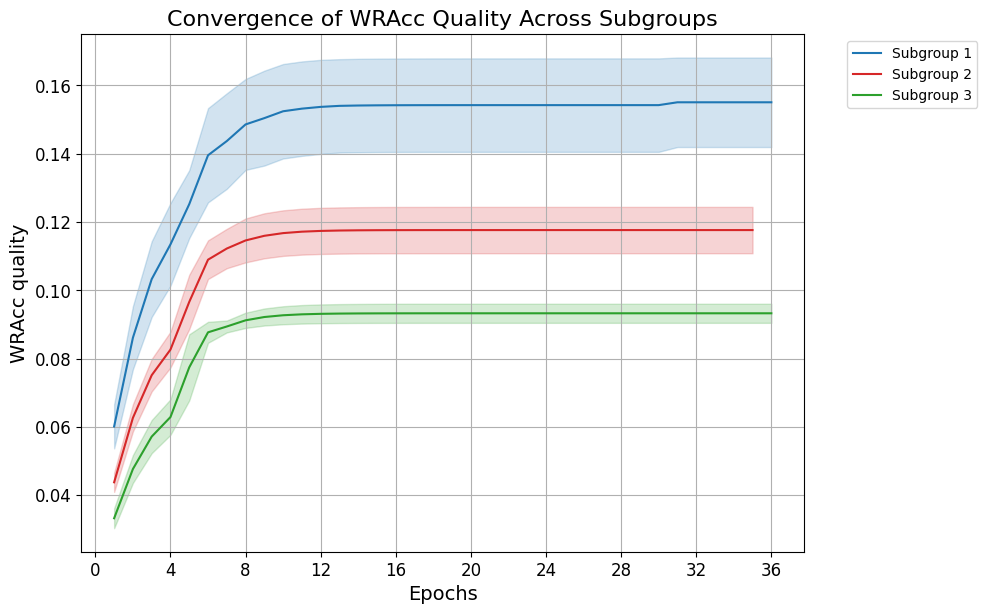

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Build tidy DataFrame
records = [
    {"iteration": i, "subgroup": j + 1, "epoch": epoch, "quality": quality}
    for i, iteration in enumerate(history)
    for j, run in enumerate(iteration)
    for epoch, quality in enumerate(run, start=1)
]
df = pd.DataFrame(records)

# Minimum last epoch for each subgroup and iteration
min_last_epoch = df.groupby(["subgroup", "iteration"])["epoch"].max().groupby("subgroup").min()
# Remove rows with epoch greater than the minimum last epoch for each subgroup
df = df.merge(min_last_epoch.rename("min_last_epoch"), on="subgroup")
df = df[df["epoch"] <= df["min_last_epoch"]]

# Aggregate across iterations: mean and std per (subgroup, epoch)
stats = df.groupby(["subgroup", "epoch"])["quality"].agg(["mean", "std"]).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tab:blue", "tab:red", "tab:green"]

for subgroup, color in zip(stats["subgroup"].unique(), colors):
    subset = stats[stats["subgroup"] == subgroup]
    ax.plot(subset["epoch"], subset["mean"], color=color, label=f"Subgroup {subgroup}")
    ax.fill_between(
        subset["epoch"],
        subset["mean"] - subset["std"],
        subset["mean"] + subset["std"],
        color=color, alpha=0.2,
    )

ax.set_xlabel("Epochs", fontsize=14)
ax.set_ylabel("WRAcc quality", fontsize=14)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(labelsize=12)
ax.grid()
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.title("Convergence of WRAcc Quality Across Subgroups", fontsize=16)
plt.show()

In [ ]:
df["relative_progress"] = 0.0
for i, row in df.iterrows():
    iteration = row["iteration"]
    subgroup = row["subgroup"]
    epoch = row["epoch"]
    max_epoch = df[(df["iteration"] == iteration) & (df["subgroup"] == subgroup)]["epoch"].max()
    start_quality = df[(df["iteration"] == iteration) & (df["subgroup"] == subgroup) & (df["epoch"] == 1.0)]["quality"].iloc[0]
    end_quality = df[(df["iteration"] == iteration) & (df["subgroup"] == subgroup) & (df["epoch"] == max_epoch)]["quality"].iloc[0]
    relative_progress = (row["quality"] - start_quality) / (end_quality - start_quality) if end_quality != start_quality else 0
    df.at[i, "relative_progress"] = relative_progress


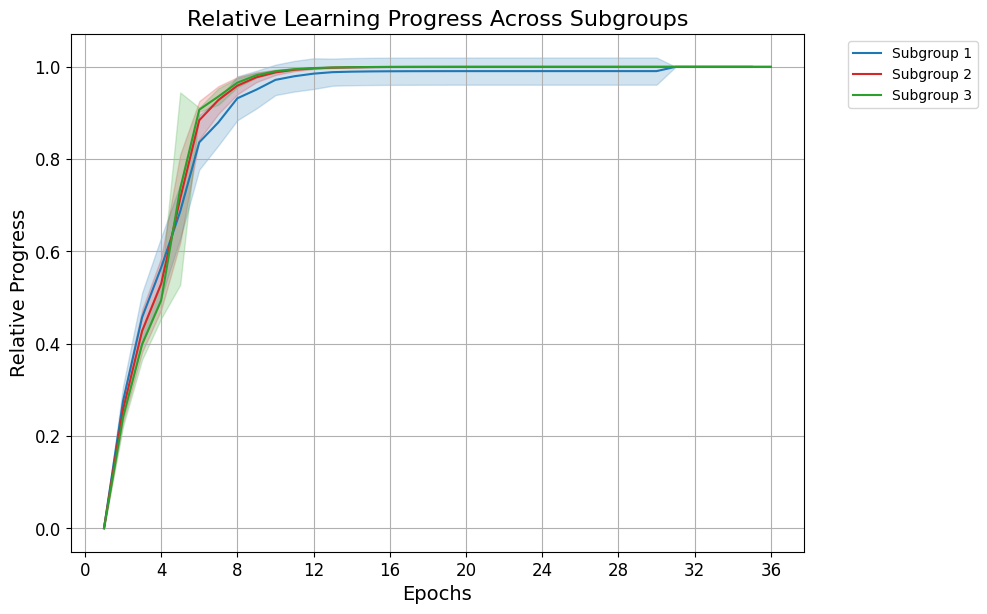

In [ ]:
# Relative progress

# Aggregate across iterations: mean and std per (subgroup, epoch)
stats = df.groupby(["subgroup", "epoch"])["relative_progress"].agg(["mean", "std"]).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
colors = ["tab:blue", "tab:red", "tab:green"]

for subgroup, color in zip(stats["subgroup"].unique(), colors):
    subset = stats[stats["subgroup"] == subgroup]
    ax.plot(subset["epoch"], subset["mean"], color=color, label=f"Subgroup {subgroup}")
    ax.fill_between(
        subset["epoch"],
        subset["mean"] - subset["std"],
        subset["mean"] + subset["std"],
        color=color, alpha=0.2,
    )

ax.set_xlabel("Epochs", fontsize=14)
ax.set_ylabel("Relative Progress", fontsize=14)
ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax.tick_params(labelsize=12)
ax.grid()
# ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.legend()
plt.tight_layout()
plt.title("Relative Learning Progress Across Subgroups", fontsize=16)
plt.show()